In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = os.path.join(os.getcwd(), "secondary-data", "merged_primary.csv")
df = pd.read_csv(file_path)

In [3]:
df.head(3)

,State,District,Block,Cluster,GP Name,GP ID,Gender,Q1,Q2,Q3,...,Q15,Q16,Q17,Q18,Q19,Q20,Unique Identifier,Year,Grade,Score
0,Karnataka,belagavi,bailhongal,ambadgatti,ambadgatti,648,female,1,1,1,...,1,1,1,1,1,0,Grade_4_22_23_1,2023,4,0.80
1,Karnataka,belagavi,bailhongal,ambadgatti,ambadgatti,648,female,0,1,1,...,0,0,0,0,1,0,Grade_4_22_23_2,2023,4,0.55
2,Karnataka,belagavi,bailhongal,ambadgatti,ambadgatti,648,female,1,0,1,...,1,1,1,0,1,1,Grade_4_22_23_3,2023,4,0.50


### Basic Exploration

In [4]:
df.shape

(1379087, 31)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1379087 entries, 0 to 1379086
Data columns (total 31 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   State              1379087 non-null  str    
 1   District           1379087 non-null  str    
 2   Block              1379087 non-null  str    
 3   Cluster            1379087 non-null  str    
 4   GP Name            1379087 non-null  str    
 5   GP ID              1379087 non-null  int64  
 6   Gender             1379087 non-null  str    
 7   Q1                 1379087 non-null  int64  
 8   Q2                 1379087 non-null  int64  
 9   Q3                 1379087 non-null  int64  
 10  Q4                 1379087 non-null  int64  
 11  Q5                 1379087 non-null  int64  
 12  Q6                 1379087 non-null  int64  
 13  Q7                 1379087 non-null  int64  
 14  Q8                 1379087 non-null  int64  
 15  Q9                 1379087 non-null  int64 

In [6]:
df.columns

Index(['State', 'District', 'Block', 'Cluster', 'GP Name', 'GP ID', 'Gender',
       'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11',
       'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20',
       'Unique Identifier', 'Year', 'Grade', 'Score'],
      dtype='str')

In [7]:
req_cols = ['State', 'District', 'Block', 'Cluster', 'GP Name', 'GP ID', 'Gender', 'Year', 'Grade', 'Score']

In [8]:
cdf = df[req_cols]

In [9]:
cdf.head()

,State,District,Block,Cluster,GP Name,GP ID,Gender,Year,Grade,Score
0,Karnataka,belagavi,bailhongal,ambadgatti,ambadgatti,648,female,2023,4,0.80
1,Karnataka,belagavi,bailhongal,ambadgatti,ambadgatti,648,female,2023,4,0.55
2,Karnataka,belagavi,bailhongal,ambadgatti,ambadgatti,648,female,2023,4,0.50
3,Karnataka,belagavi,bailhongal,ambadgatti,ambadgatti,648,female,2023,4,0.90
4,Karnataka,belagavi,bailhongal,ambadgatti,ambadgatti,648,male,2023,4,0.45


# Data Joining

In [ ]:
feat_file_path = os.path.join(os.getcwd(), "secondary-dataset", "final_master_features.csv")
feat_df = pd.read_csv(feat_file_path)

In [11]:
feat_df.head(3)

,district,year,census_total_population,census_pct_sc,census_pct_st,census_sex_ratio,census_literacy_rate_total,census_literacy_rate_male,census_literacy_rate_female,census_pct_rural_population,...,school_pct_minority,school_pct_cwsn_special,school_avg_instr_days,school_pct_covers_grade4to6,sslc_total_appeared,sslc_total_pass,sslc_pass_pct_total,sslc_pass_pct_boys,sslc_pass_pct_girls,sslc_district_rank
0,bagalkot,2023,1334568.0,18.258717,6.213247,986.848315,54.856028,64.400678,45.184177,96.80331,...,1.780415,0.127173,147.175922,52.013565,27318,23098,84.55,81.04,87.88,27
1,bagalkot,2024,1334568.0,18.258717,6.213247,986.848315,54.856028,64.400678,45.184177,96.80331,...,1.868365,0.127389,227.560934,52.144374,27239,23780,87.30,82.80,91.70,14
2,bagalkot,2025,1334568.0,18.258717,6.213247,986.848315,54.856028,64.400678,45.184177,96.80331,...,1.873138,0.127714,118.646658,52.873563,26881,21820,81.17,75.29,86.95,17


In [12]:
# Merging with features [cdf + feat_df]
merged_df = pd.merge(
    cdf, 
    feat_df, 
    left_on=["District", "Year"], 
    right_on=["district", "year"], 
    how="left"
)

In [13]:
merged_df.shape

(1379087, 64)

In [14]:
merged_df.head(3)

,State,District,Block,Cluster,GP Name,GP ID,Gender,Year,Grade,Score,...,school_pct_minority,school_pct_cwsn_special,school_avg_instr_days,school_pct_covers_grade4to6,sslc_total_appeared,sslc_total_pass,sslc_pass_pct_total,sslc_pass_pct_boys,sslc_pass_pct_girls,sslc_district_rank
0,Karnataka,belagavi,bailhongal,ambadgatti,ambadgatti,648,female,2023,4,0.80,...,7.166667,0.25,223.252917,48.708333,29340,25003,85.22,81.03,89.39,26
1,Karnataka,belagavi,bailhongal,ambadgatti,ambadgatti,648,female,2023,4,0.55,...,7.166667,0.25,223.252917,48.708333,29340,25003,85.22,81.03,89.39,26
2,Karnataka,belagavi,bailhongal,ambadgatti,ambadgatti,648,female,2023,4,0.50,...,7.166667,0.25,223.252917,48.708333,29340,25003,85.22,81.03,89.39,26


### Spatial Data Loading

In [ ]:
# Appending the District boundary
dist_file_path = os.path.join(os.getcwd(), "secondary-data", "district_bdy.csv")
dist_bdy = pd.read_csv(dist_file_path)

In [16]:
dist_bdy.head(3)

,KGISDistri,LGD_Distri,KGISDist_1,BhuCodeDis,SHAPE_STAr,SHAPE_STLe,geometry
0,1,527,belagavi,1,1.339657e+10,1.140958e+06,MULTIPOLYGON (((471438.11039999966 1848438.728...
1,2,524,bagalkot,2,6.562355e+09,6.680029e+05,POLYGON ((574602.8080000002 1814202.9605999999...
2,3,530,vijayapura,3,1.050278e+10,7.024165e+05,"POLYGON ((573312.1261 1815043.3599999994, 5731..."


In [17]:
dist_bdy = dist_bdy.rename(columns={"KGISDist_1": "District", "geometry":"dist_geometry"})

In [18]:
dist_bdy.head(3)

,KGISDistri,LGD_Distri,District,BhuCodeDis,SHAPE_STAr,SHAPE_STLe,dist_geometry
0,1,527,belagavi,1,1.339657e+10,1.140958e+06,MULTIPOLYGON (((471438.11039999966 1848438.728...
1,2,524,bagalkot,2,6.562355e+09,6.680029e+05,POLYGON ((574602.8080000002 1814202.9605999999...
2,3,530,vijayapura,3,1.050278e+10,7.024165e+05,"POLYGON ((573312.1261 1815043.3599999994, 5731..."


### Chloropleth 

### District Wise Data

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely.wkt

In [20]:
merged_df_dist = merged_df.groupby('District', as_index=False)['Score'].mean()

In [21]:
merged_df_dist

,District,Score
0,bagalkot,0.589683
1,ballari,0.422798
2,belagavi,0.656637
3,belagavi chikkodi,0.611315
4,bengaluru rural,0.615830
5,bidar,0.454034
6,chamarajanagara,0.507325
7,chikkaballapura,0.486861
8,chikkamagaluru,0.600777
9,chitradurga,0.424103


In [22]:
gcdf = dist_bdy.merge(
    merged_df_dist,
    left_on='District',   # The column in your geodata (image_c105ad.png)
    right_on='District',   # The standardized column from your main data
    how='left'
)

In [23]:
# Convert the plain text strings into actual mathematical shape objects
gcdf['dist_geometry'] = gcdf['dist_geometry'].apply(shapely.wkt.loads)

# Re-declare the merged dataframe as a GeoDataFrame
gcdf = gpd.GeoDataFrame(gcdf, geometry='dist_geometry')

In [24]:
gcdf.head(3)

,KGISDistri,LGD_Distri,District,BhuCodeDis,SHAPE_STAr,SHAPE_STLe,dist_geometry,Score
0,1,527,belagavi,1,1.339657e+10,1.140958e+06,"MULTIPOLYGON (((471438.11 1848438.728, 471446....",0.656637
1,2,524,bagalkot,2,6.562355e+09,6.680029e+05,"POLYGON ((574602.808 1814202.961, 574654.339 1...",0.589683
2,3,530,vijayapura,3,1.050278e+10,7.024165e+05,"POLYGON ((573312.126 1815043.36, 573189.527 18...",0.572833


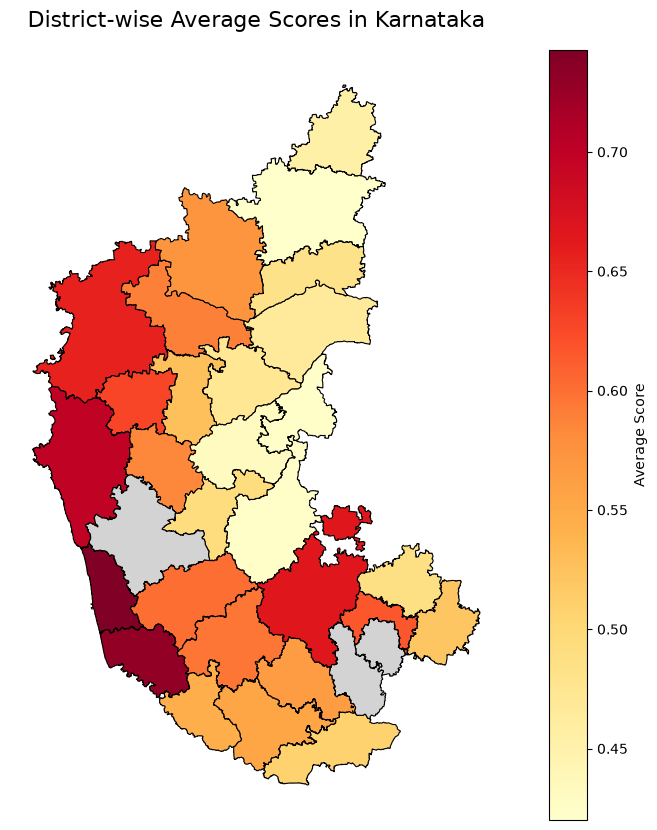

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gcdf.plot(
    column='Score',
    cmap='YlOrRd',
    linewidth=0.8,
    ax=ax,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Average Score"},
    missing_kwds={
        "color": "lightgrey",
        "label": "Missing values"
    }
)

# Formatting the map visually
plt.title("District-wise Average Scores in Karnataka", fontsize=16)
plt.axis('off')
plt.show()

# Data Visualization & Features Selection

In [26]:
# Missing Values

In [27]:
for key, val in zip(merged_df.isnull().sum().index, merged_df.isnull().sum().values):
    print(f"{key}:{val}")

State:0
District:0
Block:0
Cluster:0
GP Name:0
GP ID:0
Gender:0
Year:0
Grade:0
Score:0
district:0
year:0
census_total_population:207515
census_pct_sc:207515
census_pct_st:207515
census_sex_ratio:207515
census_literacy_rate_total:207515
census_literacy_rate_male:207515
census_literacy_rate_female:207515
census_pct_rural_population:207515
census_work_participation_rate:207515
census_pct_cultivator_workers:0
census_pct_agri_labourer_workers:0
census_pct_household_industry_workers:0
census_pct_other_workers:0
census_occupation_imputed:0
nfhs_women_ever_attended_school_pct:0
nfhs_pop_under15_pct:0
nfhs_sex_ratio:0
nfhs_sex_ratio_at_birth:0
nfhs_electricity_access_pct:0
nfhs_drinking_water_access_pct:0
nfhs_sanitation_access_pct:0
nfhs_clean_cooking_fuel_pct:0
nfhs_health_insurance_pct:0
nfhs_women_literate_pct:0
nfhs_women_10plus_yrs_schooling_pct:0
nfhs_early_marriage_pct:0
nfhs_child_stunted_pct:0
nfhs_child_wasted_pct:0
nfhs_child_underweight_pct:0
nfhs_child_anemia_pct:0
nfhs_women_anem

In [28]:
census_columns = [
    'census_total_population',
    'census_pct_sc',
    'census_pct_st',
    'census_sex_ratio',
    'census_literacy_rate_total',
    'census_literacy_rate_male',
    'census_literacy_rate_female',
    'census_pct_rural_population',
    'census_work_participation_rate',
    'census_pct_cultivator_workers',
    'census_pct_agri_labourer_workers',
    'census_pct_household_industry_workers',
    'census_pct_other_workers'
]

In [29]:
for col in census_columns:
    merged_df[col] = merged_df[col].fillna(merged_df[col].median())

# Verify that there are no more missing values
print(merged_df[census_columns].isnull().sum())

census_total_population                  0
census_pct_sc                            0
census_pct_st                            0
census_sex_ratio                         0
census_literacy_rate_total               0
census_literacy_rate_male                0
census_literacy_rate_female              0
census_pct_rural_population              0
census_work_participation_rate           0
census_pct_cultivator_workers            0
census_pct_agri_labourer_workers         0
census_pct_household_industry_workers    0
census_pct_other_workers                 0
dtype: int64


In [30]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1379087 entries, 0 to 1379086
Data columns (total 64 columns):
 #   Column                                 Non-Null Count    Dtype  
---  ------                                 --------------    -----  
 0   State                                  1379087 non-null  str    
 1   District                               1379087 non-null  str    
 2   Block                                  1379087 non-null  str    
 3   Cluster                                1379087 non-null  str    
 4   GP Name                                1379087 non-null  str    
 5   GP ID                                  1379087 non-null  int64  
 6   Gender                                 1379087 non-null  str    
 7   Year                                   1379087 non-null  int64  
 8   Grade                                  1379087 non-null  int64  
 9   Score                                  1379087 non-null  float64
 10  district                               1379087 non-nu

In [31]:
final_df = merged_df.drop(columns = ['Block', 'Cluster', 'GP Name', 'GP ID', 'district', 'year'])

In [32]:
final_df.head(3)

,State,District,Gender,Year,Grade,Score,census_total_population,census_pct_sc,census_pct_st,census_sex_ratio,...,school_pct_minority,school_pct_cwsn_special,school_avg_instr_days,school_pct_covers_grade4to6,sslc_total_appeared,sslc_total_pass,sslc_pass_pct_total,sslc_pass_pct_boys,sslc_pass_pct_girls,sslc_district_rank
0,Karnataka,belagavi,female,2023,4,0.80,1334568.0,21.732017,10.183171,974.848315,...,7.166667,0.25,223.252917,48.708333,29340,25003,85.22,81.03,89.39,26
1,Karnataka,belagavi,female,2023,4,0.55,1334568.0,21.732017,10.183171,974.848315,...,7.166667,0.25,223.252917,48.708333,29340,25003,85.22,81.03,89.39,26
2,Karnataka,belagavi,female,2023,4,0.50,1334568.0,21.732017,10.183171,974.848315,...,7.166667,0.25,223.252917,48.708333,29340,25003,85.22,81.03,89.39,26


### Creating Response Feature

In [33]:
def At_risk(x):
    if x <= 0.25:
        return "critical_risk"
    elif x > 0.25 and x <= 0.50:
        return "high_risk"
    elif x > 0.50 and x <= 0.75:
        return "moderate_risk"
    else:
        return "low_risk"
        

In [34]:
final_df["At_risk_flag"] = final_df["Score"].apply(lambda x : At_risk(x))

In [35]:
final_df

,State,District,Gender,Year,Grade,Score,census_total_population,census_pct_sc,census_pct_st,census_sex_ratio,...,school_pct_cwsn_special,school_avg_instr_days,school_pct_covers_grade4to6,sslc_total_appeared,sslc_total_pass,sslc_pass_pct_total,sslc_pass_pct_boys,sslc_pass_pct_girls,sslc_district_rank,At_risk_flag
0,Karnataka,belagavi,female,2023,4,0.80,1334568.0,21.732017,10.183171,974.848315,...,0.25,223.252917,48.708333,29340,25003,85.22,81.03,89.39,26,low_risk
1,Karnataka,belagavi,female,2023,4,0.55,1334568.0,21.732017,10.183171,974.848315,...,0.25,223.252917,48.708333,29340,25003,85.22,81.03,89.39,26,moderate_risk
2,Karnataka,belagavi,female,2023,4,0.50,1334568.0,21.732017,10.183171,974.848315,...,0.25,223.252917,48.708333,29340,25003,85.22,81.03,89.39,26,high_risk
3,Karnataka,belagavi,female,2023,4,0.90,1334568.0,21.732017,10.183171,974.848315,...,0.25,223.252917,48.708333,29340,25003,85.22,81.03,89.39,26,low_risk
4,Karnataka,belagavi,male,2023,4,0.45,1334568.0,21.732017,10.183171,974.848315,...,0.25,223.252917,48.708333,29340,25003,85.22,81.03,89.39,26,high_risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1379082,Karnataka,vijayanagar,female,2025,6,0.95,1574041.0,23.558853,21.612016,974.848315,...,0.00,98.165673,49.523242,17276,14826,85.82,82.69,88.75,10,low_risk
1379083,Karnataka,vijayanagar,female,2025,6,0.20,1574041.0,23.558853,21.612016,974.848315,...,0.00,98.165673,49.523242,17276,14826,85.82,82.69,88.75,10,critical_risk
1379084,Karnataka,vijayanagar,female,2025,6,0.25,1574041.0,23.558853,21.612016,974.848315,...,0.00,98.165673,49.523242,17276,14826,85.82,82.69,88.75,10,critical_risk
1379085,Karnataka,vijayanagar,female,2025,6,0.55,1574041.0,23.558853,21.612016,974.848315,...,0.00,98.165673,49.523242,17276,14826,85.82,82.69,88.75,10,moderate_risk


In [36]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1379087 entries, 0 to 1379086
Data columns (total 59 columns):
 #   Column                                 Non-Null Count    Dtype  
---  ------                                 --------------    -----  
 0   State                                  1379087 non-null  str    
 1   District                               1379087 non-null  str    
 2   Gender                                 1379087 non-null  str    
 3   Year                                   1379087 non-null  int64  
 4   Grade                                  1379087 non-null  int64  
 5   Score                                  1379087 non-null  float64
 6   census_total_population                1379087 non-null  float64
 7   census_pct_sc                          1379087 non-null  float64
 8   census_pct_st                          1379087 non-null  float64
 9   census_sex_ratio                       1379087 non-null  float64
 10  census_literacy_rate_total             1379087 non-nu

In [37]:
response = ['At_risk_flag']
num_features = [feat for feat in final_df.columns if (final_df[feat].dtype == 'float64' or final_df[feat].dtype == 'int64') and feat != 'Score']
cat_features = ['District', 'Gender']

### Encoding

In [38]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

In [39]:
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown= 'ignore')

In [40]:
step = [
    ('number', 'passthrough', num_features),
    ('nominal', onehot_encoder, cat_features)
]
encoder_ct = ColumnTransformer(step, verbose_feature_names_out=False).set_output(transform = 'pandas')
encoder_ct

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('number', ...), ('nominal', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transform

## Feature Selection

In [41]:
response = ['At_risk_flag']
num_features = [feat for feat in final_df.columns if (final_df[feat].dtype == 'float64' or final_df[feat].dtype == 'int64') and feat != 'Score']
cat_features = ['District', 'Gender']

In [42]:
fdf = final_df.copy()
y = fdf['At_risk_flag']
X = fdf.drop(columns = ['At_risk_flag', 'Score'])

In [43]:
# Encoded df
encoded_df = encoder_ct.fit_transform(X)

# Separate Categorical feature and numerical feature
num_df = encoded_df[num_features]
cat_df = encoded_df.drop(columns = num_features)

#### Statistical Test (Chi-Squared/ ANOVA)

In [44]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif

In [45]:
# Feature Selection of Categorical Features
# Chi-Square Test
cat_selector = SelectKBest(score_func = chi2, k = 'all')
cat_selector.fit(cat_df, y)

chi_df = pd.DataFrame({'feature': cat_selector.feature_names_in_, 'score': cat_selector.scores_, 'p-values': cat_selector.pvalues_})
chi_df = chi_df.sort_values(by = 'score', ascending=False)

display(chi_df)


,feature,score,p-values
16,District_kalaburgi,12935.865677,0.000000e+00
9,District_chitradurga,11217.346422,0.000000e+00
24,District_tumakuru,11032.535065,0.000000e+00
2,District_belagavi,10252.306907,0.000000e+00
12,District_dharwad,7405.030730,0.000000e+00
28,District_vijayanagar,6659.714326,0.000000e+00
1,District_ballari,6369.020481,0.000000e+00
3,District_belagavi chikkodi,4312.923539,0.000000e+00
22,District_raichur,3647.581227,0.000000e+00
5,District_bidar,2950.821420,0.000000e+00


In [46]:
# Feature Selection of Numerical Features
# F-Score (ANOVA)
num_selector = SelectKBest(score_func = f_classif, k = 'all')
num_selector.fit(num_df, y)

anova_df = pd.DataFrame({'feature': num_selector.feature_names_in_, 
                        'score': num_selector.scores_, 
                        'p-values': num_selector.pvalues_})
anova_df = anova_df.sort_values(by = 'score', ascending=False)

display(anova_df)

,feature,score,p-values
4,census_pct_st,15979.066859,0.000000e+00
24,nfhs_women_literate_pct,9508.185024,0.000000e+00
15,nfhs_women_ever_attended_school_pct,9176.986863,0.000000e+00
42,school_pct_cce_adopted,8991.844123,0.000000e+00
21,nfhs_sanitation_access_pct,8083.680464,0.000000e+00
3,census_pct_sc,7422.144704,0.000000e+00
25,nfhs_women_10plus_yrs_schooling_pct,7268.614425,0.000000e+00
51,sslc_pass_pct_girls,6942.123991,0.000000e+00
28,nfhs_child_wasted_pct,6095.864881,0.000000e+00
49,sslc_pass_pct_total,5362.767902,0.000000e+00


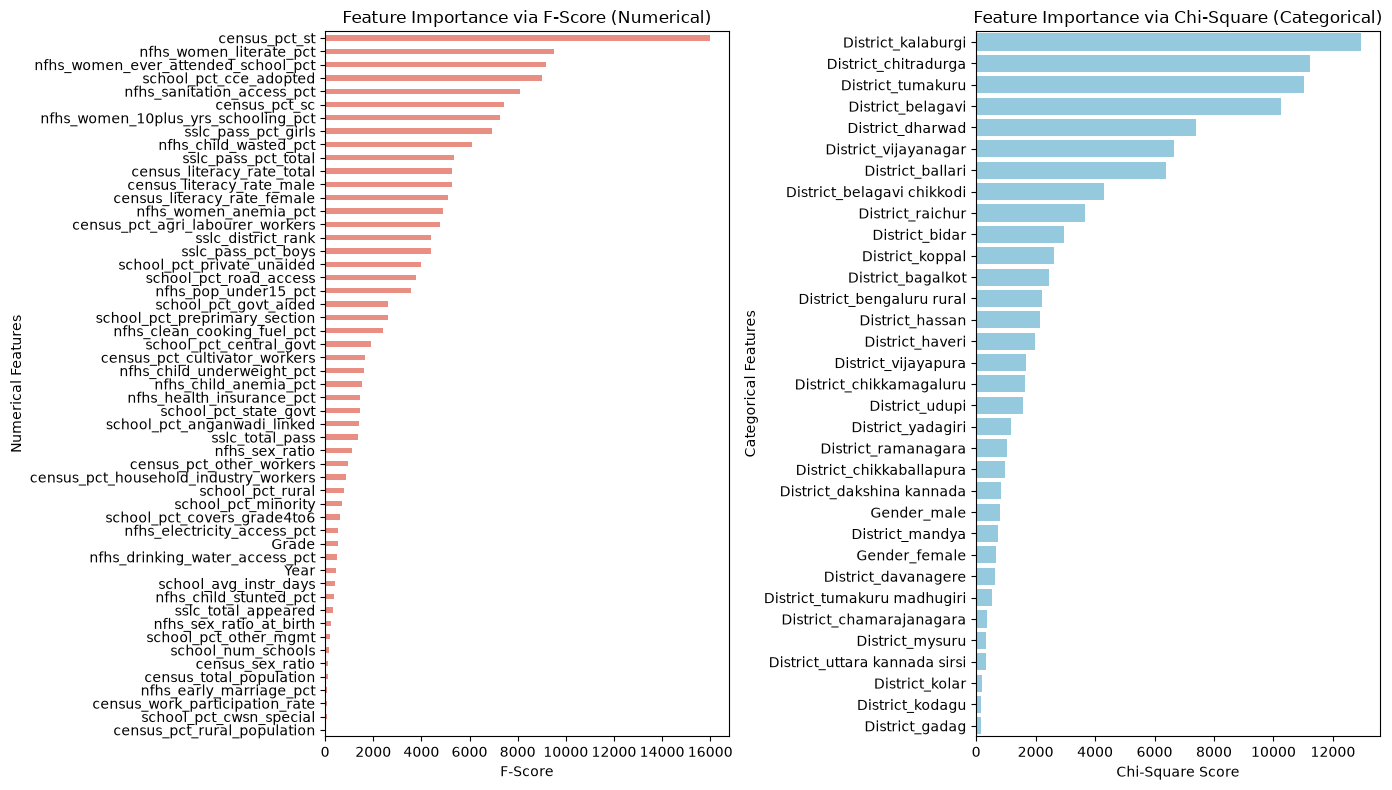

In [47]:
# Create the figure and two subplots side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 8))

sns.barplot(data=anova_df, x='score', y='feature', color='salmon', ax=ax[0], width=0.4)
ax[0].set_title('Feature Importance via F-Score (Numerical)')
ax[0].set_xlabel('F-Score')
ax[0].set_ylabel('Numerical Features')

sns.barplot(data=chi_df, x='score', y='feature', color='skyblue', ax=ax[1])
ax[1].set_title('Feature Importance via Chi-Square (Categorical)')
ax[1].set_xlabel('Chi-Square Score')
ax[1].set_ylabel('Categorical Features')

plt.tight_layout()
plt.show()

In [48]:
## Finding Significant Numerical Features
# alpha
alpha = 0.01

significant_df = anova_df[anova_df['p-values'] < alpha].copy()
significant_df = significant_df.sort_values(by=['p-values', 'score'], ascending=[True, False])
# display(significant_df)

In [49]:
# If you need to extract just the significant feature names as a list for your model pipeline:
final_num_features = significant_df['feature'].tolist()

### Standardization

In [50]:
from sklearn.preprocessing import StandardScaler

In [51]:
num_features = [feat for feat in final_df.columns if (final_df[feat].dtype == 'float64' or final_df[feat].dtype == 'int64') and feat != 'Score']

In [52]:
# Feature Scaling (Standardization)
scaler = StandardScaler()

## Final Preprocessing Pipeline after feature selection

In [53]:
response = ['At_risk_flag']
cat_features = ['District', 'Gender']
final_num_features = significant_df['feature'].tolist()

In [54]:
scaler = StandardScaler()
onehot_encoder = OneHotEncoder(sparse_output = False, handle_unknown= 'ignore')

step = [
    ('number', scaler, final_num_features),
    ('nominal', onehot_encoder, cat_features)
]
preprocessor_ct = ColumnTransformer(step, verbose_feature_names_out=False).set_output(transform = 'pandas')
preprocessor_ct

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('number', ...), ('nominal', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transform

## Splitting Of Dataset

In [55]:
from sklearn.preprocessing import LabelEncoder

In [56]:
fdf = final_df.copy()

In [57]:
# Encoding the response variable before splitting
le = LabelEncoder()
fdf['At_risk_flag'] = le.fit_transform(fdf['At_risk_flag'])
print(le.classes_)
print(dict(zip(le.classes_, le.transform(le.classes_))))

['critical_risk' 'high_risk' 'low_risk' 'moderate_risk']
{'critical_risk': np.int64(0), 'high_risk': np.int64(1), 'low_risk': np.int64(2), 'moderate_risk': np.int64(3)}


In [58]:
# 2. Split the data based on the 'year' column
train_df = fdf[fdf['Year'] != 2025]
test_df = fdf[fdf['Year'] == 2025]

# 3. Define features (X) and target (y) for the Training set
y_train = train_df['At_risk_flag']
# Reminder: Drop 'year' here as well if you don't want the model to train on it
X_train = train_df.drop(columns=['At_risk_flag', 'Score'])

# 4. Define features (X) and target (y) for the Test set
y_test = test_df['At_risk_flag']
X_test = test_df.drop(columns=['At_risk_flag', 'Score'])

## Modelling + Evaluation

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_score, 
    recall_score, 
    roc_auc_score, 
    roc_curve, 
    confusion_matrix, 
    classification_report
)
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

In [60]:
def training(model_pipeline, X_train, y_train):
    for model_name in model_pipeline.keys():
        model_pipeline[model_name].fit(X_train, y_train)
        print(f'Training of {model_name} Completed!')

In [67]:
def eval_summary_df(model_pipeline, X, y, average_method='macro', cls_report=True):
    df = pd.DataFrame(columns=['Accuracy', 'Macro_Recall', 'Macro_Precision', 'Macro_F1', 'AUC'], 
                      index=model_pipeline.keys())
    
    for model_name, clf in model_pipeline.items():
        y_pred = clf.predict(X)
        y_pred_prob = clf.predict_proba(X)
        
        df.loc[model_name, 'Accuracy'] = accuracy_score(y, y_pred)
        df.loc[model_name, 'Macro_Recall'] = recall_score(y, y_pred, average=average_method)
        df.loc[model_name, 'Macro_Precision'] = precision_score(y, y_pred, average=average_method, zero_division=0)
        df.loc[model_name, 'Macro_F1'] = f1_score(y, y_pred, average=average_method)
        df.loc[model_name, 'AUC'] = roc_auc_score(y, y_pred_prob, multi_class='ovr', average=average_method)
        
        if cls_report:
            print(f"\n==================== Classification Report: {model_name} ====================")
            print(classification_report(y, y_pred, target_names=le.classes_, zero_division=0))
            
    return df

In [68]:
def PlotConfMatrix(model_pipeline, X, y, cls_report=False):
    for model_name in model_pipeline.keys():
        clf = model_pipeline[model_name]
        y_pred = clf.predict(X)
        conf_matrix = confusion_matrix(y, y_pred)
        
        print('--' * 30)
        print(f'Details of {model_name}')
        print('--' * 30)
        
        if cls_report:
            report = classification_report(y, y_pred)
            print(f'\nClassification Report of {model_name}:\n', report)
            
        plt.figure(figsize=(6, 5))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Confusion Matrix of {model_name}')
        plt.show()

In [69]:
# Feature Selected Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

models_pipe = {}
for name, model in models.items():
    models_pipe[name] = Pipeline([
        ('preprocessor', preprocessor_ct),
        ('model', model)
    ])

# Fit Baseline and Feature Selected Pipelines
training(models_pipe, X_train, y_train)

Training of Logistic Regression Completed!
Training of Decision Tree Completed!
Training of Random Forest Completed!


In [70]:
# Evaluate on Test Set
print('Testing Model')
print('---' * 30)
display(eval_summary_df(models_pipe, X_test, y_test, average_method='weighted'))

Testing Model
------------------------------------------------------------------------------------------

==================== Classification Report: Logistic Regression ====================
               precision    recall  f1-score   support

critical_risk       0.24      0.40      0.30    139754
    high_risk       0.24      0.23      0.23    140716
     low_risk       0.23      0.34      0.28    150980
moderate_risk       0.00      0.00      0.00    164078

     accuracy                           0.24    595528
    macro avg       0.18      0.24      0.20    595528
 weighted avg       0.17      0.24      0.20    595528


==================== Classification Report: Decision Tree ====================
               precision    recall  f1-score   support

critical_risk       0.32      0.25      0.28    139754
    high_risk       0.26      0.03      0.05    140716
     low_risk       0.31      0.55      0.39    150980
moderate_risk       0.26      0.33      0.29    164078

     accu

,Accuracy,Macro_Recall,Macro_Precision,Macro_F1,AUC
Logistic Regression,0.236073,0.236073,0.170886,0.195846,0.500109
Decision Tree,0.293126,0.293126,0.286381,0.257182,0.550194
Random Forest,0.303227,0.303227,0.299688,0.267727,0.562734


In [72]:
rf_pipe = Pipeline([
    ('preprocessor', preprocessor_ct),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1))
])

In [75]:
from sklearn.model_selection import RandomizedSearchCV

# Define search distributions
param_distributions = {
    'model__n_estimators': [100, 150, 200, 300],
    'model__max_depth': [8, 12, 16, 20],
    'model__min_samples_split': [2, 5, 10, 15],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__max_features': ['sqrt', 'log2', 0.3],
    'model__criterion': ['gini', 'entropy']
}

random_search_rf = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_distributions,
    n_iter=6,             
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=1,
    verbose=2
)

random_search_rf.fit(X_train, y_train)

best_rf_pipe = random_search_rf.best_estimator_

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END model__criterion=entropy, model__max_depth=12, model__max_features=0.3, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=200; total time=  24.6s
[CV] END model__criterion=entropy, model__max_depth=12, model__max_features=0.3, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=200; total time=  17.8s
[CV] END model__criterion=entropy, model__max_depth=12, model__max_features=0.3, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=200; total time=  18.7s
[CV] END model__criterion=entropy, model__max_depth=20, model__max_features=log2, model__min_samples_leaf=8, model__min_samples_split=2, model__n_estimators=300; total time=  16.1s
[CV] END model__criterion=entropy, model__max_depth=20, model__max_features=log2, model__min_samples_leaf=8, model__min_samples_split=2, model__n_estimators=300; total time=  16.9s
[CV] END model__criterion=entropy, mod

In [77]:
best_rf_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](4,)","[0,1,2,3]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['State','District','Gender',...,'sslc_pass_pct_boys', 'sslc_pass_pct_girls','sslc_district_rank']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('number', ...), ('nominal', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that f

In [80]:
# Evaluate on Test Set
print('Testing Model')
print('---' * 30)

# Pass best_rf_pipe inside a dictionary
display(eval_summary_df({'Tuned Random Forest': best_rf_pipe}, X_test, y_test, average_method='macro'))

Testing Model
------------------------------------------------------------------------------------------

==================== Classification Report: Tuned Random Forest ====================
               precision    recall  f1-score   support

critical_risk       0.32      0.53      0.40    139754
    high_risk       0.26      0.16      0.20    140716
     low_risk       0.32      0.55      0.40    150980
moderate_risk       0.30      0.04      0.08    164078

     accuracy                           0.31    595528
    macro avg       0.30      0.32      0.27    595528
 weighted avg       0.30      0.31      0.27    595528



,Accuracy,Macro_Recall,Macro_Precision,Macro_F1,AUC
Tuned Random Forest,0.31219,0.319397,0.301212,0.270623,0.578946
